# Breast Cancer Prediction — Consolidated Dual-Scenario ML Pipeline

A reproducible notebook implementing strict Train/Validation/Test separation, leakage auditing, SMOTENC, model tuning, threshold selection, final held-out testing, calibration, bootstrap confidence intervals, subgroup analysis, SHAP explainability, cost-sensitive analysis, and artifact serialization.

**Scenarios**
- **Pre-Diagnostic Risk Model:** excludes diagnostic findings and definitive staging.
- **Diagnostic-Assessment Model:** retains selected clinical/imaging findings while excluding biopsy result and confirmed stage.

Before presentation, verify the dataset source and how `Cancer` was generated. The diagnostic scenario must not contain variables that directly define the target.

In [1]:
# 0. CONFIGURATION
from pathlib import Path
import os, json, warnings, datetime, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE=42
DATA_PATH=Path("../data/raw/breast_cancer_prediction.csv")
ARTIFACT_DIR=Path("../models"); FIGURE_DIR=Path("../reports/figures"); REPORT_DIR=Path("../reports")
for p in [ARTIFACT_DIR,FIGURE_DIR,REPORT_DIR]: p.mkdir(parents=True,exist_ok=True)
print(DATA_PATH.resolve())

D:\WORK\Antigravity\BREAST_CANCER_DETECTION_CNZ\Breast_Cancer_Detection_Project\data\raw\breast_cancer_prediction.csv


In [2]:
# 1. IMPORTS
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,confusion_matrix,precision_recall_curve,roc_curve,brier_score_loss
from sklearn.calibration import calibration_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from xgboost import XGBClassifier
import shap
print("Imports complete")

Imports complete


In [3]:
# 2. LOAD + QUALITY
if not DATA_PATH.exists(): raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")
df=pd.read_csv(DATA_PATH)
print("Initial shape:",df.shape)
display(df.head())
print("Missing values:")
miss=df.isna().sum().rename("count").to_frame(); miss["pct"]=miss["count"]/len(df)*100; display(miss[miss["count"]>0].sort_values("count",ascending=False))
before=len(df); df=df.drop_duplicates().copy(); print("Duplicates removed:",before-len(df))
if "Cancer" not in df.columns: raise ValueError("Target 'Cancer' not found")
print("Target distribution:"); display(df["Cancer"].value_counts().sort_index().to_frame("count"))
print("Target %:"); display((df["Cancer"].value_counts(normalize=True).sort_index()*100).round(2).to_frame("pct"))

Initial shape: (10000, 23)


,Patient_ID,Age,Gender,BMI,Family_History,Smoking,Alcohol_Consumption,Physical_Activity,Hormone_Therapy,Menopause_Status,...,Mammogram_Result,Biopsy_Result,Cancer_Stage,Cancer,Blood_Pressure,Cholesterol,Diabetes,Exercise_Days_Per_Week,Breastfeeding_History,Annual_Income_USD
0,100001,71,Female,27.2,Yes,Yes,Yes,High,No,Post,...,Suspicious,Malignant,Stage II,1,141,167,No,7,No,101316
1,100002,34,Male,26.0,No,No,No,High,No,Post,...,Normal,Benign,No Cancer,0,104,229,Yes,7,Yes,30023
2,100003,80,Female,20.7,No,No,No,High,No,Pre,...,Suspicious,Benign,No Cancer,0,161,275,No,1,Yes,34819
3,100004,40,Female,26.8,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,150,180,No,7,Yes,68025
4,100005,43,Female,28.6,Yes,Yes,No,Moderate,No,Post,...,Normal,Benign,No Cancer,0,110,266,No,0,Yes,90919


Missing values:


,count,pct
BMI,300,3.0
Alcohol_Consumption,300,3.0
Physical_Activity,300,3.0
Hormone_Therapy,300,3.0
Tumor_Size_cm,300,3.0


Duplicates removed: 0
Target distribution:


,count
Cancer,
0,8067
1,1933


Target %:


,pct
Cancer,
0,80.67
1,19.33


## 3. Target / leakage audit
The audit below is not used for model selection. It documents relationships between the target and variables that may be downstream of diagnosis. Confirm the dataset-generation process before making any clinical claim.

In [4]:
# 3. TARGET / LEAKAGE AUDIT
diagnostic_cols=["Biopsy_Result","Cancer_Stage","Mammogram_Result","Lymph_Node_Involvement","Tumor_Size_cm"]
avail=[c for c in diagnostic_cols if c in df.columns]
print("Potentially downstream columns:",avail)
for c in avail:
    print(f"\n--- {c} ---")
    if pd.api.types.is_numeric_dtype(df[c]):
        display(df.groupby("Cancer")[c].agg(["count","mean","median","std"]))
    else:
        display(pd.crosstab(df[c],df["Cancer"],margins=True))
print("\nMANUAL CHECK: identify exactly how Cancer was generated and when each feature becomes available.")

Potentially downstream columns: ['Biopsy_Result', 'Cancer_Stage', 'Mammogram_Result', 'Lymph_Node_Involvement', 'Tumor_Size_cm']

--- Biopsy_Result ---


Cancer,0,1,All
Biopsy_Result,,,
Benign,8067,0,8067
Malignant,0,1933,1933
All,8067,1933,10000



--- Cancer_Stage ---


Cancer,0,1,All
Cancer_Stage,,,
No Cancer,8067,0,8067
Stage I,0,745,745
Stage II,0,602,602
Stage III,0,395,395
Stage IV,0,191,191
All,8067,1933,10000



--- Mammogram_Result ---


...


--- Lymph_Node_Involvement ---


Cancer,0,1,All
Lymph_Node_Involvement,,,
No,6832,1145,7977
Yes,1235,788,2023
All,8067,1933,10000



--- Tumor_Size_cm ---


,count,mean,median,std
Cancer,,,,
0,7813,2.460161,2.31,1.546253
1,1887,3.334923,3.46,1.574046



MANUAL CHECK: identify exactly how Cancer was generated and when each feature becomes available.


In [5]:
# 4. SCENARIOS
PRE_DROP=["Patient_ID","Biopsy_Result","Cancer_Stage","Mammogram_Result","Lymph_Node_Involvement","Tumor_Size_cm"]
DIAGNOSTIC_DROP=["Patient_ID","Biopsy_Result","Cancer_Stage"]
SCENARIOS={"pre_diagnostic":PRE_DROP,"diagnostic_assessment":DIAGNOSTIC_DROP}
for k,v in SCENARIOS.items(): print(k,"-> drop",v)

pre_diagnostic -> drop ['Patient_ID', 'Biopsy_Result', 'Cancer_Stage', 'Mammogram_Result', 'Lymph_Node_Involvement', 'Tumor_Size_cm']
diagnostic_assessment -> drop ['Patient_ID', 'Biopsy_Result', 'Cancer_Stage']


In [6]:
# 5. HELPERS
def make_splits(X,y):
    Xtr,Xtmp,ytr,ytmp=train_test_split(X,y,test_size=.30,stratify=y,random_state=RANDOM_STATE)
    Xv,Xte,yv,yte=train_test_split(Xtmp,ytmp,test_size=.50,stratify=ytmp,random_state=RANDOM_STATE)
    return Xtr,Xv,Xte,ytr,yv,yte

def build_preprocessor(X):
    cats=X.select_dtypes(include=["object","category","bool"]).columns.tolist(); nums=X.select_dtypes(include=[np.number]).columns.tolist()
    numpipe=SklearnPipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
    catpipe=SklearnPipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))])
    prep=ColumnTransformer([("num",numpipe,nums),("cat",catpipe,cats)])
    cat_idx=list(range(len(nums),len(nums)+len(cats)))
    return prep,nums,cats,cat_idx

def model_space():
    return {
      "Logistic Regression":(LogisticRegression(random_state=RANDOM_STATE,max_iter=2000),{"classifier__C":[.01,.1,1,10],"classifier__class_weight":[None,"balanced"]}),
      "Random Forest":(RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1),{"classifier__n_estimators":[100,200,300],"classifier__max_depth":[None,10,20],"classifier__min_samples_leaf":[1,2,5],"classifier__class_weight":[None,"balanced"]}),
      "XGBoost":(XGBClassifier(random_state=RANDOM_STATE,eval_metric="logloss",n_jobs=1,tree_method="hist"),{"classifier__n_estimators":[50,100,200],"classifier__learning_rate":[.01,.05,.1,.2],"classifier__max_depth":[3,5,7],"classifier__subsample":[.8,1.0],"classifier__colsample_bytree":[.8,1.0]})}

def metrics(y,p,t):
    yp=(np.asarray(p)>=t).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel()
    return {"threshold":float(t),"accuracy":accuracy_score(y,yp),"precision":precision_score(y,yp,zero_division=0),"recall":recall_score(y,yp,zero_division=0),"specificity":tn/(tn+fp) if tn+fp else 0,"npv":tn/(tn+fn) if tn+fn else 0,"f1":f1_score(y,yp,zero_division=0),"roc_auc":roc_auc_score(y,p),"pr_auc":average_precision_score(y,p),"brier":brier_score_loss(y,p),"tn":int(tn),"fp":int(fp),"fn":int(fn),"tp":int(tp)}

def optimize_f2(y,p):
    prec,rec,thr=precision_recall_curve(y,p); f2=(5*prec[:-1]*rec[:-1])/(4*prec[:-1]+rec[:-1]+1e-12); i=int(np.nanargmax(f2)); return float(thr[i]),float(f2[i])

def bootstrap_ci(y,p,t,fn,n=1000,seed=RANDOM_STATE):
    rng=np.random.default_rng(seed); vals=[]; y=np.asarray(y); p=np.asarray(p)
    for _ in range(n):
        idx=rng.integers(0,len(y),len(y)); yt=y[idx]; pt=p[idx]
        try:
            v=fn(yt,pt,t)
            if np.isfinite(v): vals.append(v)
        except Exception: pass
    return (float(np.percentile(vals,2.5)),float(np.percentile(vals,97.5))) if vals else (np.nan,np.nan)

def r_metric(y,p,t): return recall_score(y,(p>=t).astype(int),zero_division=0)
def pp_metric(y,p,t): return precision_score(y,(p>=t).astype(int),zero_division=0)
def f1_metric(y,p,t): return f1_score(y,(p>=t).astype(int),zero_division=0)
def auc_metric(y,p,t): return roc_auc_score(y,p)
def ap_metric(y,p,t): return average_precision_score(y,p)
def safe_save(path): plt.tight_layout(); plt.savefig(path,dpi=180,bbox_inches="tight"); plt.show()

## 6. Training / selection
Hyperparameters are selected by cross-validated ROC-AUC on the training partition. The validation partition is then used to choose the champion and threshold. The final test partition is not used for these decisions.

In [7]:
# 6. MAIN PIPELINE
model_results={}; rows=[]
for scenario,dropcols in SCENARIOS.items():
    print("="*80); print("SCENARIO:",scenario)
    scene=df.drop(columns=[c for c in dropcols if c in df.columns]).copy(); X=scene.drop(columns=["Cancer"]); y=scene["Cancer"].astype(int)
    Xtr,Xv,Xte,ytr,yv,yte=make_splits(X,y); print("Train",Xtr.shape,"Val",Xv.shape,"Test",Xte.shape)
    prep,nums,cats,cat_idx=build_preprocessor(Xtr)
    if not cats: raise ValueError("SMOTENC requires categorical columns; use SMOTE if dataset becomes all-numeric.")
    sampler=SMOTENC(categorical_features=cat_idx,random_state=RANDOM_STATE)
    cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=RANDOM_STATE)
    candidates=[]
    for name,(clf,params) in model_space().items():
        pipe=ImbPipeline([("preprocessor",prep),("sampler",sampler),("classifier",clf)])
        search=RandomizedSearchCV(pipe,params,n_iter=10,scoring="roc_auc",cv=cv,random_state=RANDOM_STATE,n_jobs=-1,refit=True)
        search.fit(Xtr,ytr); tuned=search.best_estimator_
        pv=tuned.predict_proba(Xv)[:,1]; t,f2=optimize_f2(yv,pv); vm=metrics(yv,pv,t); vm["f2"]=f2
        candidates.append({"model_name":name,"pipeline":tuned,"best_params":search.best_params_,"cv_best_roc_auc":float(search.best_score_),"val_metrics":vm,"X_train":Xtr,"X_val":Xv,"X_test":Xte,"y_train":ytr,"y_val":yv,"y_test":yte,"numerical_cols":nums,"categorical_cols":cats})
        print(name,search.best_params_,"| CV",round(search.best_score_,4),"| Val recall",round(vm["recall"],4),"| Val PR-AUC",round(vm["pr_auc"],4),"| thr",round(t,4))
    candidates.sort(key=lambda c:(c["val_metrics"]["recall"],c["val_metrics"]["pr_auc"],c["val_metrics"]["specificity"]),reverse=True)
    champ=candidates[0]; pte=champ["pipeline"].predict_proba(Xte)[:,1]; tm=metrics(yte,pte,champ["val_metrics"]["threshold"])
    print("CHAMPION:",champ["model_name"]); print("TEST:",tm)
    model_results[scenario]={"champion":champ,"test_prob_raw":pte,"test_metrics_raw":tm,"candidates":candidates}
    rows.append({"scenario":scenario,"champion":champ["model_name"],"threshold":champ["val_metrics"]["threshold"],"test_roc_auc":tm["roc_auc"],"test_pr_auc":tm["pr_auc"],"test_recall":tm["recall"],"test_specificity":tm["specificity"],"test_precision":tm["precision"],"test_npv":tm["npv"],"test_f1":tm["f1"],"test_accuracy":tm["accuracy"]})
final_summary=pd.DataFrame(rows); display(final_summary)

SCENARIO: pre_diagnostic
Train (7000, 16) Val (1500, 16) Test (1500, 16)


Logistic Regression {'classifier__class_weight': None, 'classifier__C': 0.1} | CV 0.8561 | Val recall 0.831 | Val PR-AUC 0.6321 | thr 0.4032


Random Forest {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced'} | CV 0.872 | Val recall 0.9345 | Val PR-AUC 0.6484 | thr 0.2299


XGBoost {'classifier__subsample': 1.0, 'classifier__n_estimators': 50, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8} | CV 0.8812 | Val recall 0.9276 | Val PR-AUC 0.6838 | thr 0.3395
CHAMPION: Random Forest
TEST: {'threshold': 0.22988068091503486, 'accuracy': 0.6773333333333333, 'precision': 0.36639118457300274, 'recall': 0.9172413793103448, 'specificity': np.float64(0.6198347107438017), 'npv': np.float64(0.9689922480620154), 'f1': 0.5236220472440944, 'roc_auc': 0.8642519236249645, 'pr_auc': 0.6505802308770849, 'brier': 0.1225398725369236, 'tn': 750, 'fp': 460, 'fn': 24, 'tp': 266}
SCENARIO: diagnostic_assessment
Train (7000, 19) Val (1500, 19) Test (1500, 19)


Logistic Regression {'classifier__class_weight': None, 'classifier__C': 1} | CV 0.9303 | Val recall 0.9069 | Val PR-AUC 0.7824 | thr 0.3529


Random Forest {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None, 'classifier__class_weight': None} | CV 0.9787 | Val recall 0.9724 | Val PR-AUC 0.9476 | thr 0.4315


XGBoost {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.8} | CV 0.9926 | Val recall 0.9621 | Val PR-AUC 0.9847 | thr 0.6203
CHAMPION: Random Forest
TEST: {'threshold': 0.4314526737352825, 'accuracy': 0.93, 'precision': 0.7534246575342466, 'recall': 0.9482758620689655, 'specificity': np.float64(0.9256198347107438), 'npv': np.float64(0.986784140969163), 'f1': 0.8396946564885496, 'roc_auc': 0.9829210601310916, 'pr_auc': 0.9520877670178544, 'brier': 0.060183195192250336, 'tn': 1120, 'fp': 90, 'fn': 15, 'tp': 275}


,scenario,champion,threshold,test_roc_auc,test_pr_auc,test_recall,test_specificity,test_precision,test_npv,test_f1,test_accuracy
0,pre_diagnostic,Random Forest,0.229881,0.864252,0.650580,0.917241,0.619835,0.366391,0.968992,0.523622,0.677333
1,diagnostic_assessment,Random Forest,0.431453,0.982921,0.952088,0.948276,0.925620,0.753425,0.986784,0.839695,0.930000


In [8]:
# 7. VALIDATION MODEL COMPARISON
val_rows=[]
for scenario,res in model_results.items():
    for c in res["candidates"]:
        vm=c["val_metrics"]; val_rows.append({"scenario":scenario,"model":c["model_name"],"cv_roc_auc":c["cv_best_roc_auc"],"val_roc_auc":vm["roc_auc"],"val_pr_auc":vm["pr_auc"],"val_recall":vm["recall"],"val_precision":vm["precision"],"val_specificity":vm["specificity"],"val_f1":vm["f1"],"threshold":vm["threshold"]})
validation_comparison=pd.DataFrame(val_rows); display(validation_comparison.sort_values(["scenario","val_recall","val_pr_auc"],ascending=[True,False,False]))

,scenario,model,cv_roc_auc,val_roc_auc,val_pr_auc,val_recall,val_precision,val_specificity,val_f1,threshold
3,diagnostic_assessment,Random Forest,0.978678,0.985363,0.947595,0.972414,0.752000,0.923140,0.848120,0.431453
4,diagnostic_assessment,XGBoost,0.992564,0.994192,0.984747,0.962069,0.945763,0.986777,0.953846,0.620281
5,diagnostic_assessment,Logistic Regression,0.930332,0.928994,0.782385,0.906897,0.519763,0.799174,0.660804,0.352854
0,pre_diagnostic,Random Forest,0.872024,0.879923,0.648373,0.934483,0.397361,0.660331,0.557613,0.229881
1,pre_diagnostic,XGBoost,0.881153,0.885004,0.683756,0.927586,0.403298,0.671074,0.562173,0.339521
2,pre_diagnostic,Logistic Regression,0.856087,0.858179,0.632148,0.831034,0.425044,0.730579,0.562427,0.403227


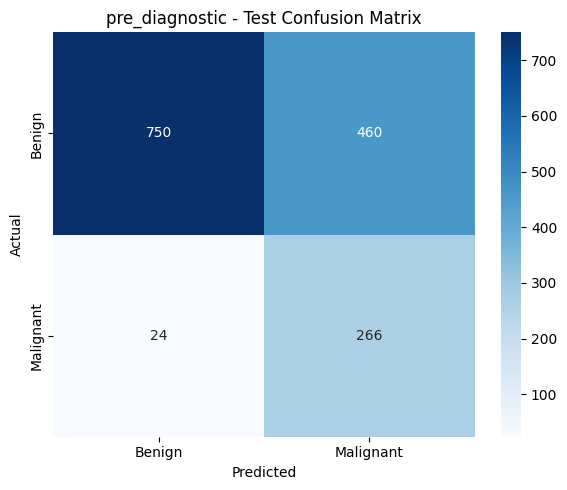

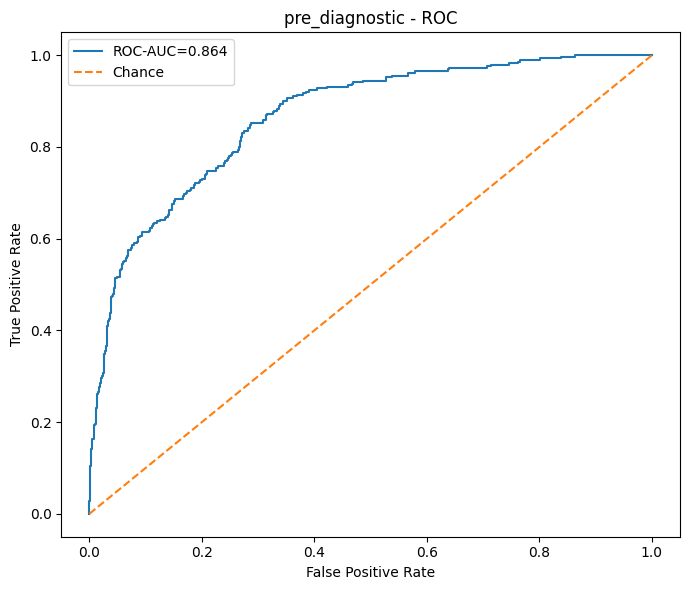

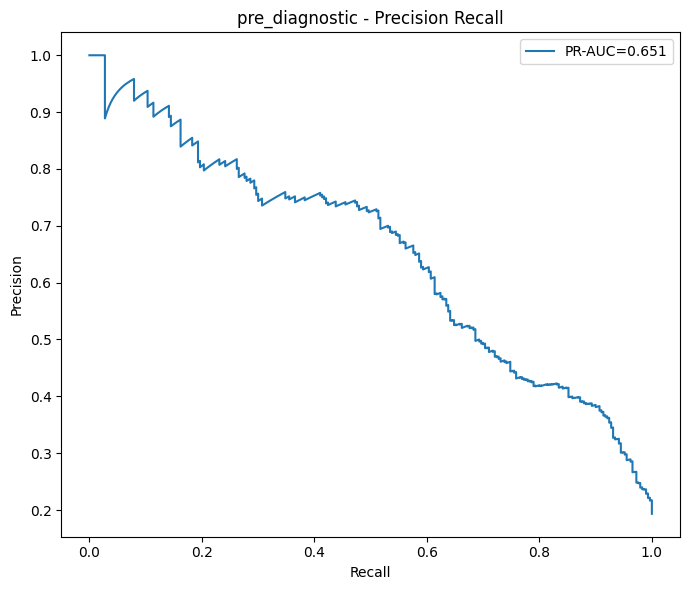

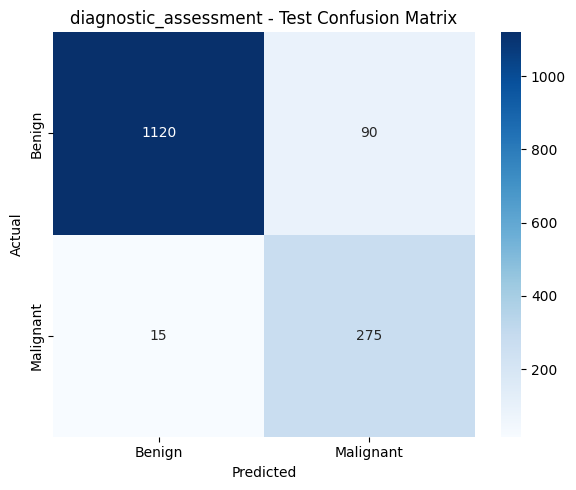

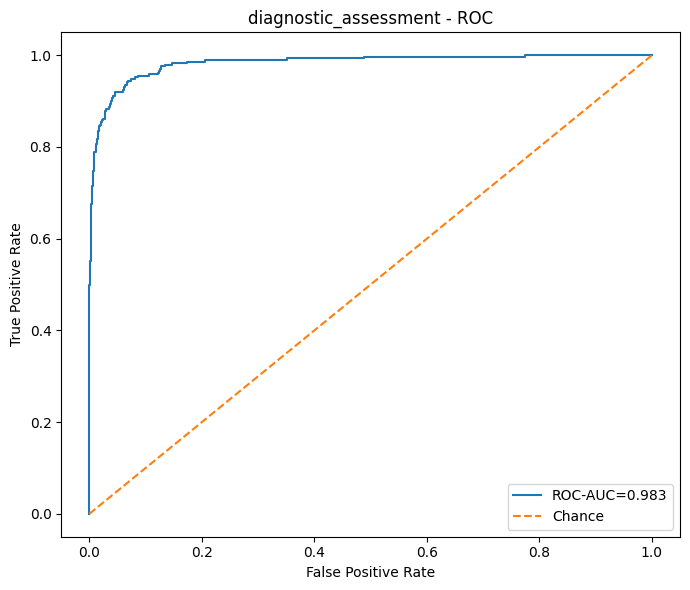

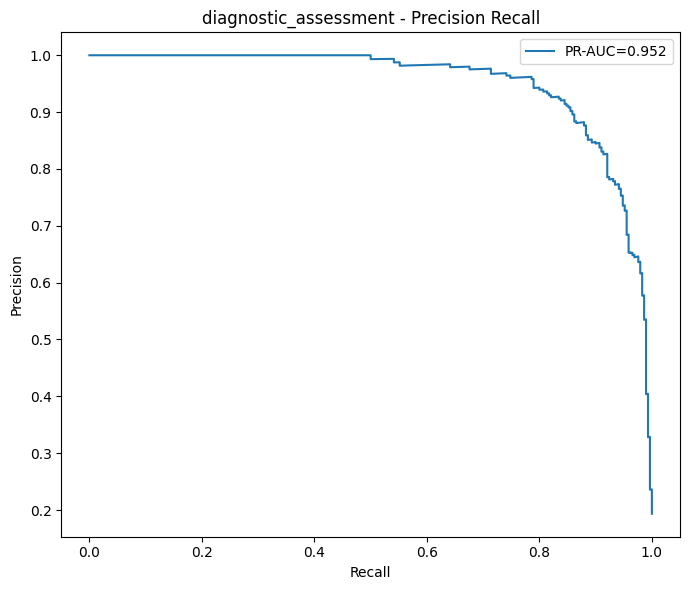

In [9]:
# 8. FINAL CONFUSION MATRICES + ROC/PR
for scenario,res in model_results.items():
    ch=res["champion"]; y=ch["y_test"]; p=res["test_prob_raw"]; t=ch["val_metrics"]["threshold"]; yp=(p>=t).astype(int)
    cm=confusion_matrix(y,yp,labels=[0,1])
    plt.figure(figsize=(6,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Benign","Malignant"],yticklabels=["Benign","Malignant"]); plt.title(f"{scenario} - Test Confusion Matrix"); plt.ylabel("Actual"); plt.xlabel("Predicted"); safe_save(FIGURE_DIR/f"{scenario}_confusion_matrix.png")
    fpr,tpr,_=roc_curve(y,p); plt.figure(figsize=(7,6)); plt.plot(fpr,tpr,label=f"ROC-AUC={roc_auc_score(y,p):.3f}"); plt.plot([0,1],[0,1],"--",label="Chance"); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title(f"{scenario} - ROC"); plt.legend(); safe_save(FIGURE_DIR/f"{scenario}_roc.png")
    pr,rc,_=precision_recall_curve(y,p); plt.figure(figsize=(7,6)); plt.plot(rc,pr,label=f"PR-AUC={average_precision_score(y,p):.3f}"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{scenario} - Precision Recall"); plt.legend(); safe_save(FIGURE_DIR/f"{scenario}_pr.png")

## 9. Calibration

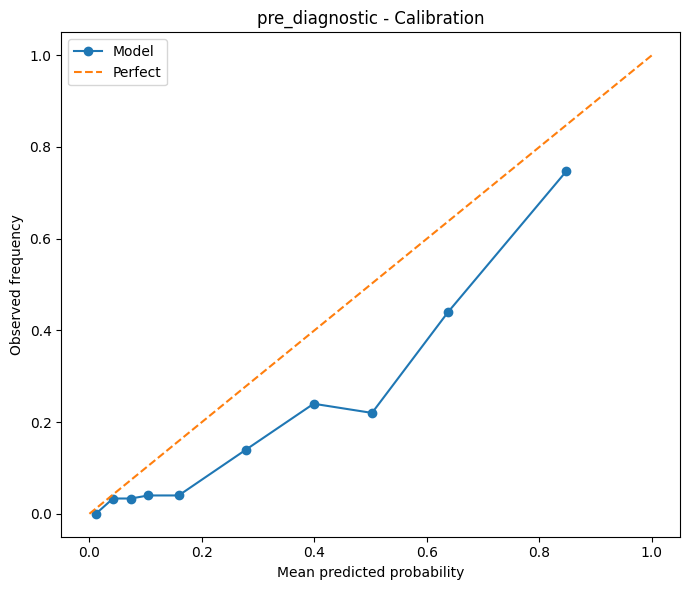

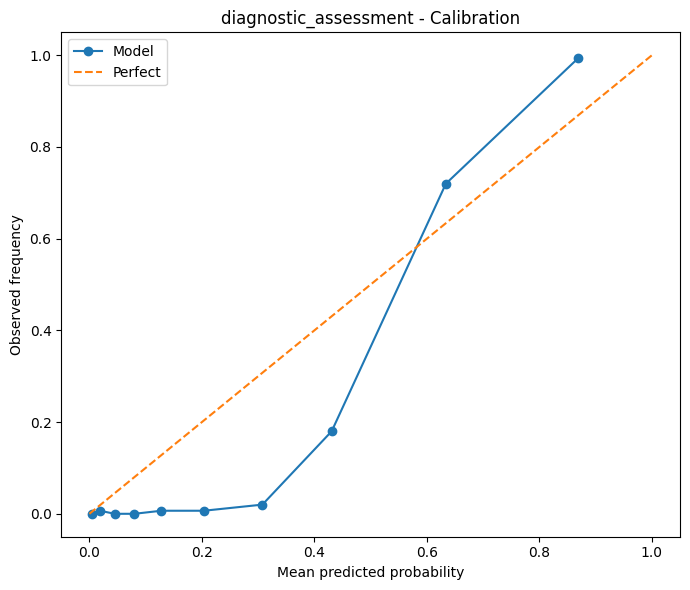

,scenario,brier_score
0,pre_diagnostic,0.122540
1,diagnostic_assessment,0.060183


In [10]:
# 9. CALIBRATION + BRIER SCORE
cal_rows=[]
for scenario,res in model_results.items():
    ch=res["champion"]; y=ch["y_test"]; p=res["test_prob_raw"]; frac,mean=calibration_curve(y,p,n_bins=10,strategy="quantile")
    plt.figure(figsize=(7,6)); plt.plot(mean,frac,marker="o",label="Model"); plt.plot([0,1],[0,1],"--",label="Perfect"); plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency"); plt.title(f"{scenario} - Calibration"); plt.legend(); safe_save(FIGURE_DIR/f"{scenario}_calibration.png")
    cal_rows.append({"scenario":scenario,"brier_score":brier_score_loss(y,p)})
calibration_df=pd.DataFrame(cal_rows); display(calibration_df)

## 10. Bootstrap 95% confidence intervals

In [11]:
# 10. BOOTSTRAP CIs
boot_rows=[]
fnmap={"Recall":r_metric,"Precision":pp_metric,"F1":f1_metric,"ROC-AUC":auc_metric,"PR-AUC":ap_metric}
for scenario,res in model_results.items():
    ch=res["champion"]; y=ch["y_test"].to_numpy(); p=res["test_prob_raw"]; t=ch["val_metrics"]["threshold"]
    for name,fn in fnmap.items():
        point=fn(y,p,t); lo,hi=bootstrap_ci(y,p,t,fn,n=1000); boot_rows.append({"scenario":scenario,"metric":name,"estimate":point,"ci95_low":lo,"ci95_high":hi})
bootstrap_df=pd.DataFrame(boot_rows); display(bootstrap_df)

,scenario,metric,estimate,ci95_low,ci95_high
0,pre_diagnostic,Recall,0.917241,0.884363,0.947963
1,pre_diagnostic,Precision,0.366391,0.332843,0.398672
2,pre_diagnostic,F1,0.523622,0.486098,0.558050
3,pre_diagnostic,ROC-AUC,0.864252,0.842178,0.885643
4,pre_diagnostic,PR-AUC,0.650580,0.592605,0.703096
5,diagnostic_assessment,Recall,0.948276,0.921498,0.971734
6,diagnostic_assessment,Precision,0.753425,0.706880,0.798414
7,diagnostic_assessment,F1,0.839695,0.808046,0.867517
8,diagnostic_assessment,ROC-AUC,0.982921,0.974716,0.989761
9,diagnostic_assessment,PR-AUC,0.952088,0.934445,0.966170


## 11. Subgroup analysis
This is a robustness/fairness diagnostic, not a certification of fairness.

In [12]:
# 11. AGE / GENDER SUBGROUPS
def subgroup(X,y,p,t,col):
    if col not in X.columns: return pd.DataFrame()
    tmp=pd.DataFrame({col:X[col].values,"y":np.asarray(y),"p":np.asarray(p)})
    out=[]
    for g,d in tmp.groupby(col,dropna=False):
        if d.y.nunique()<2: continue
        m=metrics(d.y,d.p,t); out.append({"group":g,"n":len(d),"recall":m["recall"],"specificity":m["specificity"],"precision":m["precision"],"npv":m["npv"],"roc_auc":m["roc_auc"]})
    return pd.DataFrame(out)
for scenario,res in model_results.items():
    ch=res["champion"]; X=ch["X_test"].copy(); y=ch["y_test"]; p=res["test_prob_raw"]; t=ch["val_metrics"]["threshold"]
    if "Age" in X.columns:
        X["Age_Group"]=pd.cut(X["Age"],bins=[-np.inf,39,59,np.inf],labels=["<40","40-59","60+"]); print(scenario,"Age"); display(subgroup(X,y,p,t,"Age_Group"))
    if "Gender" in X.columns:
        print(scenario,"Gender"); display(subgroup(X,y,p,t,"Gender"))

pre_diagnostic Age


,group,n,recall,specificity,precision,npv,roc_auc
0,<40,433,0.900000,0.796345,0.365854,0.983871,0.899739
1,40-59,459,0.893333,0.622396,0.316038,0.967611,0.862951
2,60+,608,0.933333,0.465011,0.393862,0.949309,0.831138


pre_diagnostic Gender


,group,n,recall,specificity,precision,npv,roc_auc
0,Female,1396,0.916667,0.619258,0.359584,0.969571,0.866504
1,Male,104,0.923077,0.628205,0.452830,0.960784,0.851085


diagnostic_assessment Age


,group,n,recall,specificity,precision,npv,roc_auc
0,<40,433,0.900000,0.976501,0.833333,0.986807,0.990914
1,40-59,459,0.946667,0.906250,0.663551,0.988636,0.974236
2,60+,608,0.963636,0.898420,0.779412,0.985149,0.983911


diagnostic_assessment Gender


,group,n,recall,specificity,precision,npv,roc_auc
0,Female,1396,0.954545,0.924028,0.745562,0.988658,0.983289
1,Male,104,0.884615,0.948718,0.851852,0.961039,0.981755


## 12. SHAP explainability
SHAP values are model-attribution explanations, not causal explanations.

SHAP: pre_diagnostic


  0%|          | 0/20 [00:00<?, ?it/s]

,feature,mean_abs_shap
0,Age,0.140003
3,Family_History,0.121707
4,Smoking,0.113614
2,BMI,0.094080
9,Genetic_Mutation,0.062151
11,Cholesterol,0.009520
10,Blood_Pressure,0.009167
15,Annual_Income_USD,0.008688
12,Diabetes,0.008088
5,Alcohol_Consumption,0.007246


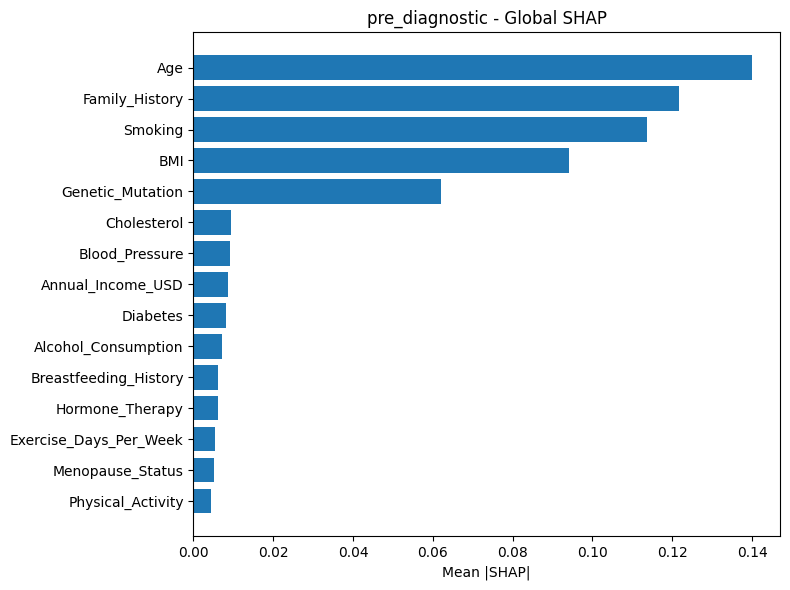

,feature,value,shap_value,abs_shap
3,Family_History,Yes,0.182187,0.182187
0,Age,36,-0.165338,0.165338
4,Smoking,No,-0.128866,0.128866
2,BMI,28.9,-0.045594,0.045594
9,Genetic_Mutation,Negative,-0.022560,0.022560
15,Annual_Income_USD,142445,0.022384,0.022384
10,Blood_Pressure,119,0.016517,0.016517
14,Breastfeeding_History,Yes,-0.013719,0.013719
7,Hormone_Therapy,No,0.007522,0.007522
6,Physical_Activity,High,0.000000,0.000000


SHAP: diagnostic_assessment


  0%|          | 0/20 [00:00<?, ?it/s]

,feature,mean_abs_shap
0,Age,0.106196
4,Smoking,0.100696
3,Family_History,0.100372
10,Tumor_Size_cm,0.086981
11,Lymph_Node_Involvement,0.083498
2,BMI,0.065982
12,Mammogram_Result,0.063081
9,Genetic_Mutation,0.041069
15,Diabetes,0.004689
18,Annual_Income_USD,0.003596


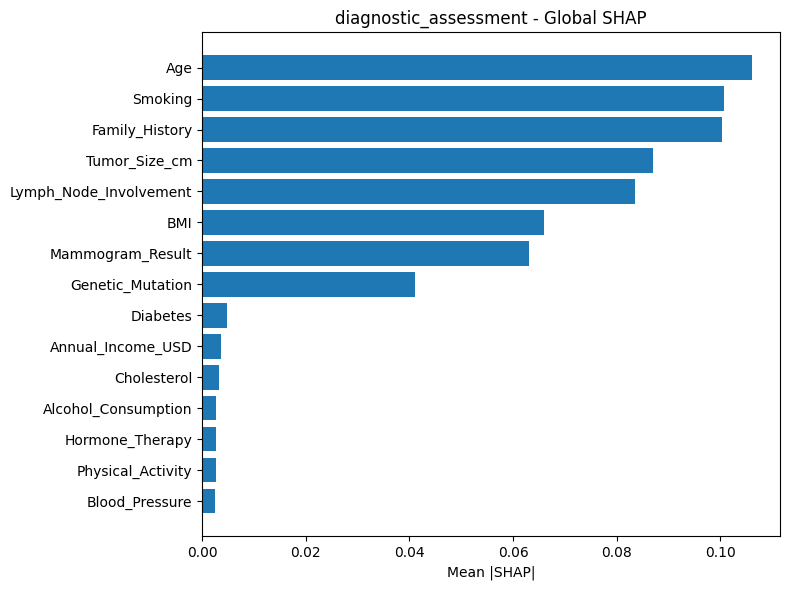

,feature,value,shap_value,abs_shap
3,Family_History,Yes,0.120239,0.120239
12,Mammogram_Result,Suspicious,0.118953,0.118953
0,Age,36,-0.117421,0.117421
4,Smoking,No,-0.106806,0.106806
10,Tumor_Size_cm,1.92,-0.095781,0.095781
11,Lymph_Node_Involvement,No,-0.046347,0.046347
2,BMI,28.9,-0.027399,0.027399
9,Genetic_Mutation,Negative,-0.019717,0.019717
6,Physical_Activity,High,-0.008159,0.008159
14,Cholesterol,192,-0.002418,0.002418


In [13]:
# 12. SHAP GLOBAL + LOCAL
shap_outputs={}
for scenario,res in model_results.items():
    ch=res["champion"]; pipe=ch["pipeline"]; Xtr=ch["X_train"]; Xte=ch["X_test"]
    bg=Xtr.sample(min(50,len(Xtr)),random_state=RANDOM_STATE); sample=Xte.sample(min(20,len(Xte)),random_state=RANDOM_STATE)
    def pred(arr): return pipe.predict_proba(pd.DataFrame(arr,columns=Xtr.columns))[:,1]
    print("SHAP:",scenario); explainer=shap.KernelExplainer(pred,bg); vals=explainer.shap_values(sample,nsamples=100);
    if isinstance(vals,list): vals=vals[-1]
    vals=np.asarray(vals); shap_outputs[scenario]={"explainer":explainer,"values":vals,"sample":sample}
    imp=pd.DataFrame({"feature":sample.columns,"mean_abs_shap":np.abs(vals).mean(axis=0)}).sort_values("mean_abs_shap",ascending=False)
    display(imp.head(15))
    top=imp.head(15).sort_values("mean_abs_shap"); plt.figure(figsize=(8,6)); plt.barh(top.feature,top.mean_abs_shap); plt.xlabel("Mean |SHAP|"); plt.title(f"{scenario} - Global SHAP"); safe_save(FIGURE_DIR/f"{scenario}_shap_global.png")
    local=pd.DataFrame({"feature":sample.columns,"value":sample.iloc[0].astype(str).values,"shap_value":vals[0]}); local["abs_shap"]=local.shap_value.abs(); display(local.sort_values("abs_shap",ascending=False).head(10))

## 13. Illustrative cost-sensitive analysis
The dollar values below are assumptions for a decision-analysis demonstration, not real healthcare costs.

In [14]:
# 13. COST SCENARIO
COST_FP=5000; COST_FN=100000
cost_rows=[]
for scenario,res in model_results.items():
    ch=res["champion"]; y=ch["y_test"].to_numpy(); p=res["test_prob_raw"]; t=ch["val_metrics"]["threshold"]; yp=(p>=t).astype(int); tn,fp,fn,tp=confusion_matrix(y,yp,labels=[0,1]).ravel(); cost=fp*COST_FP+fn*COST_FN
    cost_rows.append({"scenario":scenario,"threshold":t,"FP":fp,"FN":fn,"TP":tp,"TN":tn,"FP_cost_assumption":COST_FP,"FN_cost_assumption":COST_FN,"illustrative_total_cost":cost})
cost_df=pd.DataFrame(cost_rows); display(cost_df)

,scenario,threshold,FP,FN,TP,TN,FP_cost_assumption,FN_cost_assumption,illustrative_total_cost
0,pre_diagnostic,0.229881,460,24,266,750,5000,100000,4700000
1,diagnostic_assessment,0.431453,90,15,275,1120,5000,100000,1950000


## 14. Save artifacts

In [15]:
# 14. SERIALIZE MODELS + REPORTS
metadata={}
for scenario,res in model_results.items():
    ch=res["champion"]; joblib.dump(ch["pipeline"],ARTIFACT_DIR/f"{scenario}_pipeline.pkl")
    metadata[scenario]={"dataset_version":"v3_consolidated","saved_utc":datetime.datetime.now(datetime.timezone.utc).isoformat(),"model_name":ch["model_name"],"best_parameters":ch["best_params"],"threshold":float(ch["val_metrics"]["threshold"]),"features":ch["X_train"].columns.tolist(),"categorical_columns":ch["categorical_cols"],"numerical_columns":ch["numerical_cols"],"validation_metrics":{k:float(v) if isinstance(v,(np.floating,float)) else v for k,v in ch["val_metrics"].items()},"final_test_metrics":{k:float(v) if isinstance(v,(np.floating,float)) else v for k,v in res["test_metrics_raw"].items()},"note":"External validation and prospective clinical evaluation are required before deployment."}
with open(ARTIFACT_DIR/"model_metadata.json","w",encoding="utf-8") as f: json.dump(metadata,f,indent=4)
final_summary.to_csv(REPORT_DIR/"final_scenario_summary.csv",index=False); validation_comparison.to_csv(REPORT_DIR/"validation_model_comparison.csv",index=False); bootstrap_df.to_csv(REPORT_DIR/"bootstrap_confidence_intervals.csv",index=False); calibration_df.to_csv(REPORT_DIR/"calibration_summary.csv",index=False); cost_df.to_csv(REPORT_DIR/"illustrative_cost_analysis.csv",index=False)
print("Artifacts saved to",ARTIFACT_DIR.resolve())

Artifacts saved to D:\WORK\Antigravity\BREAST_CANCER_DETECTION_CNZ\Breast_Cancer_Detection_Project\models


# 15. Final jury checklist

- [ ] Dataset source is documented.
- [ ] `Cancer` target-generation logic is known.
- [ ] Prediction timepoint for each scenario is explicitly defined.
- [ ] No target-derived feature is retained.
- [ ] Train/validation/test separation is preserved.
- [ ] Hyperparameter tuning uses training CV only.
- [ ] Threshold selection uses validation only.
- [ ] Test set is used only for final reporting.
- [ ] Sensitivity/recall, specificity, PPV/precision, NPV, F1, ROC-AUC and PR-AUC are reported.
- [ ] Calibration and Brier score are reported.
- [ ] Bootstrap confidence intervals are reported.
- [ ] Subgroup analysis is shown.
- [ ] SHAP is described as attribution, not causality.
- [ ] Cost analysis is explicitly labeled illustrative.
- [ ] External validation limitations are stated.

**Recommended claim:** “We developed and evaluated a dual-scenario breast-cancer classification pipeline with leakage-aware feature definition, mixed-type imbalance handling, validation-based threshold optimization, held-out testing, calibration, uncertainty estimation and interpretability.”